 Author : **Muhammad Taha** \
 Date : 27/01/2026 \
 Email : contact.taha2005@gmail.com 
 

# 💳 **Credit Card Fraud Detection**
### Using Logistic Regression with Business-Driven Threshold Optimization

---

## 🏢 Business Context

Credit card fraud is a multi-billion dollar problem. Financial institutions lose an estimated **$32 billion annually** to fraudulent transactions worldwide. The challenge is not just technical — it is a **high-stakes business decision problem**.

### Business Framework

| | |
|---|---|
| **Entity** | Cardholder |
| **Event** | Fraudulent transaction occurring |
| **Action** | Block card / Flag for manual review / Allow transaction |
| **Business Metric** | Fraud loss prevented vs. customer friction caused |

### Two Types of Errors — Both Have Real Costs

| Error Type | What Happens | Business Impact |
|---|---|---|
| **False Negative (FN)** | Fraud predicted as Normal | 💸 Financial loss — fraud goes undetected |
| **False Positive (FP)** | Normal predicted as Fraud | 😡 Customer frustration — legitimate transaction blocked |

> **Key Insight:** In fraud detection, a 99.8% accurate model that predicts everything as "normal" is **completely useless**. We must optimize for the right metric, not just accuracy.

---

## 📦 Step 1 — Import Libraries

We import the core libraries required for data manipulation, visualization, and model building.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


## 📂 Step 2 — Load Dataset

We load the **Kaggle Credit Card Fraud Detection dataset**, which contains transactions made by European cardholders in September 2013.

| Feature | Description |
|---|---|
| `Time` | Seconds elapsed between this transaction and the first transaction |
| `V1–V28` | PCA-transformed features (anonymized for confidentiality) |
| `Amount` | Transaction amount in EUR |
| `Class` | **Target variable** — 1 = Fraud, 0 = Legitimate |

> **Business Note:** The features V1–V28 are anonymized due to PCI-DSS compliance requirements. Real-world fraud models must respect data privacy regulations while still being actionable.

In [4]:
df = pd.read_csv('data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## ⚠️ Step 3 — Class Imbalance Analysis

This is one of the most critical business-relevant steps. The dataset is **severely imbalanced**.

### Why does this matter?

A naive model that **always predicts "Normal"** would achieve ~99.8% accuracy — yet it would be completely worthless for a fraud team.

> **Business Implication:** If we deploy an accuracy-optimized model without addressing imbalance, we essentially build a system that ignores every fraud case. The bank would continue losing money while believing the model is performing well.


In [5]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

 
### Imbalance Ratio

```
Fraudulent transactions:  492   (~0.17%)
Legitimate transactions:  284,315 (~99.83%)
```

**Strategies to handle imbalance:**
- `class_weight='balanced'` — penalizes misclassifying the minority class more heavily
- Resampling (SMOTE, undersampling) — synthetically balance the dataset
- Threshold tuning — shift decision boundary away from default 0.5

## ✂️ Step 4 — Train/Test Split

We split data into **70% training** and **30% testing** using `stratify=y` to ensure both splits maintain the same fraud-to-legitimate ratio.

> **Business Note:** Stratified splitting is mandatory in imbalanced datasets. Without it, the test set might contain zero fraud cases, making evaluation meaningless.

In [6]:
from sklearn.model_selection import train_test_split
X = df.drop('Class', axis=1)
y = df['Class']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

## ⚙️ Step 5 — Feature Scaling

We apply `StandardScaler` to `Time` and `Amount` — the only two non-PCA features in the dataset.

> **Why scale?** Logistic Regression is sensitive to the magnitude of features. `Amount` can range from €0 to €25,000+, while `Time` spans 172,792 seconds. Without scaling, these features would dominate the model's gradients.

> **Business Note:** We fit the scaler **only on training data** and apply it to test data. Fitting on the full dataset would constitute **data leakage** — the model would have indirect knowledge of the test distribution, inflating performance metrics unrealistically.

In [7]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train[['Time', 'Amount']] = scaler.fit_transform(X_train[['Time', 'Amount']])
X_test[['Time', 'Amount']] = scaler.transform(X_test[['Time', 'Amount']])

## 🤖 Step 6 — Model Training

We train a **Logistic Regression** classifier with `class_weight='balanced'`.

### Why Logistic Regression?

| Property | Value for Fraud Detection |
|---|---|
| **Interpretability** | High — coefficients can be explained to compliance/risk teams |
| **Speed** | Fast to train and score — important for real-time transaction screening |
| **Probability output** | Returns fraud probability per transaction — not just a binary flag |
| **Regulatory acceptance** | Widely accepted in banking due to explainability (vs. black-box models) |

### Why `class_weight='balanced'`?

Without this, the model is biased toward the majority class (legitimate transactions).  
Setting `class_weight='balanced'` automatically adjusts loss weights inversely proportional to class frequencies:

```
Weight for class 0 (Normal) = n_samples / (2 × n_normal)
Weight for class 1 (Fraud)  = n_samples / (2 × n_fraud)
```

> **Business Impact:** This forces the model to pay ~577x more attention to each fraud case compared to a normal transaction — reflecting the real-world cost asymmetry.

In [8]:
model = LogisticRegression(class_weight='balanced', max_iter=1000)
model.fit(X_train, y_train)

# Predictions at default threshold (0.5)
predictions = model.predict(X_test)

# Probability estimates for each class
prob = model.predict_proba(X_test)

print(f"Model trained successfully on {X_train.shape[0]:,} samples")
print(f"Default Accuracy: {accuracy_score(y_test, predictions):.4f}")

Model trained successfully on 199,364 samples
Default Accuracy: 0.9787


## 📊 Step 7 — Initial Model Evaluation

We first evaluate the model using the **default threshold of 0.5** to establish a baseline.

### Why accuracy is NOT the right metric here

| Metric | Why it matters |
|---|---|
| **Accuracy** | Misleading — high even if all fraud cases missed |
| **Precision** | Of all flagged transactions, how many are actually fraud? |
| **Recall** | Of all actual fraud cases, how many did we catch? |
| **F1-Score** | Harmonic mean of precision and recall |
| **ROC-AUC** | Model's ability to discriminate between fraud and legitimate |

> **Critical Business Question:** What is more expensive — missing a fraud (FN) or blocking a legitimate customer (FP)?  
> The answer determines the threshold we choose and which metric we optimize.

  EVALUATION AT DEFAULT THRESHOLD (0.5)

  Accuracy : 0.9787
  ROC-AUC  : 0.9679

              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99     85295
       Fraud       0.07      0.88      0.12       148

    accuracy                           0.98     85443
   macro avg       0.53      0.93      0.56     85443
weighted avg       1.00      0.98      0.99     85443



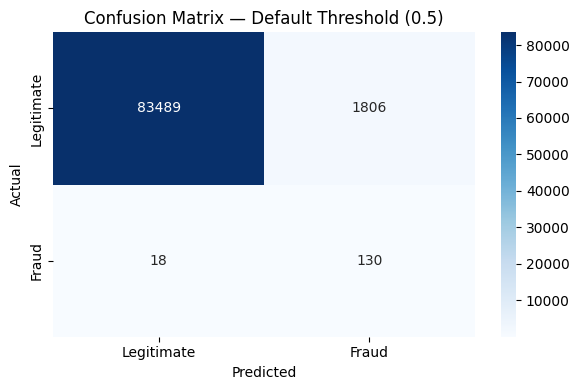

In [9]:
from sklearn.metrics import roc_auc_score

# --- Evaluation at Default Threshold (0.5) ---
print("=" * 55)
print("  EVALUATION AT DEFAULT THRESHOLD (0.5)")
print("=" * 55)
print(f"\n  Accuracy : {accuracy_score(y_test, predictions):.4f}")
print(f"  ROC-AUC  : {roc_auc_score(y_test, prob[:, 1]):.4f}")
print(f"\n{classification_report(y_test, predictions, target_names=['Legitimate', 'Fraud'])}")

# --- Confusion Matrix ---
fig, ax = plt.subplots(figsize=(6, 4))
cm = confusion_matrix(y_test, predictions)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix — Default Threshold (0.5)')
plt.tight_layout()
plt.show()

### Interpreting the Confusion Matrix

| Quadrant | Meaning |
|---|---|
| **True Negative (TN)** — Top-left | Correctly identified as legitimate |
| **False Positive (FP)** — Top-right | Legitimate transaction flagged as fraud (customer friction) |
| **False Negative (FN)** — Bottom-left | Fraud missed by model (financial loss) |
| **True Positive (TP)** — Bottom-right | Correctly caught fraud (money saved) |

> **Business Observation:** At the default threshold of 0.5 with `class_weight='balanced'`, the model achieves high recall (catches most fraud) but produces some false positives. This is expected — the balanced weighting pushes the model toward catching fraud aggressively. The next step is to fine-tune the **decision threshold** to align with business priorities.

## 🎯 Step 8 — Custom Threshold Tuning

**This is the most business-critical step in the entire notebook.**

The default threshold of 0.5 assumes equal cost for False Positives and False Negatives — which is rarely true in real-world fraud detection.

### The Threshold Trade-off

| Threshold | Effect | Business Use Case |
|---|---|---|
| **Lower (e.g. 0.2)** | More fraud caught (↑ Recall), more false alarms (↓ Precision) | When fraud loss >> investigation cost |
| **Higher (e.g. 0.7)** | Fewer false alarms (↑ Precision), more fraud missed (↓ Recall) | When customer friction is expensive |
| **0.5 (default)** | Balanced, but not optimized for business reality | Generic baseline only |

### Business Scenario

Suppose:
- Average fraud loss per missed case = **€120**
- Cost to investigate a false alert (ops team time) = **€5**

Then we should **aggressively lower the threshold** to maximize recall, because missing fraud is 24× more costly than a false investigation.

> The optimal threshold is a **business decision**, not a statistical one. It requires input from fraud operations, risk management, and finance teams.

In [10]:
y_pred_proba = prob[:, 1]

# --- Impact of Different Thresholds on Fraud Detection Performance ---
thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

print(f"{'Threshold':>10} | {'Precision':>10} | {'Recall':>10} | {'F1-Score':>10} | {'Fraud Caught':>13} | {'False Alarms':>13}")
print("-" * 85)

for t in thresholds_to_test:
    preds_t = (y_pred_proba >= t).astype(int)
    report = classification_report(y_test, preds_t, output_dict=True, zero_division=0)
    fraud_caught = preds_t[y_test == 1].sum()
    false_alarms = preds_t[y_test == 0].sum()
    total_fraud = y_test.sum()
    print(f"{t:>10.1f} | {report['1']['precision']:>10.4f} | {report['1']['recall']:>10.4f} | "
          f"{report['1']['f1-score']:>10.4f} | {fraud_caught:>6d}/{total_fraud:<6d} | {false_alarms:>13,}")

 Threshold |  Precision |     Recall |   F1-Score |  Fraud Caught |  False Alarms
-------------------------------------------------------------------------------------
       0.1 |     0.0099 |     0.9392 |     0.0195 |    139/148    |        13,948
       0.2 |     0.0194 |     0.9122 |     0.0380 |    135/148    |         6,817
       0.3 |     0.0314 |     0.8986 |     0.0607 |    133/148    |         4,100
       0.4 |     0.0467 |     0.8784 |     0.0886 |    130/148    |         2,656
       0.5 |     0.0671 |     0.8784 |     0.1248 |    130/148    |         1,806
       0.6 |     0.0951 |     0.8649 |     0.1714 |    128/148    |         1,218
       0.7 |     0.1331 |     0.8581 |     0.2305 |    127/148    |           827
       0.8 |     0.1805 |     0.8514 |     0.2979 |    126/148    |           572


### Key Observations from Threshold Analysis

- **Lowering the threshold** catches more fraud (higher recall) but increases false alarms
- **Raising the threshold** reduces false alarms but misses more actual fraud cases
- The **optimal operating point** depends on the business cost ratio: `Cost(FN) / Cost(FP)`

> **Business Decision Framework:**
> - If `Cost(FN) >> Cost(FP)` → Lower threshold (prioritize recall) — **fraud-loss-minimization**
> - If `Cost(FN) ≈ Cost(FP)` → Use F1-optimal threshold — **balanced approach**
> - If customer experience is critical → Use precision-recall equilibrium — **customer-first approach**
> - If regulatory FPR cap exists → Use ROC-based threshold — **compliance-driven approach**

Next, we use two systematic methods to find the optimal threshold: **ROC Curve** and **Precision-Recall Curve**.

## 📈 Step 9 — ROC Curve & Optimal Threshold (FPR ≤ 5%)

The **ROC (Receiver Operating Characteristic) Curve** plots True Positive Rate (Recall) vs. False Positive Rate across all possible thresholds.

### What is the FPR ≤ 5% Constraint?

We find the threshold where **False Positive Rate ≤ 0.05**, meaning:
- At most **5% of legitimate transactions** will be incorrectly flagged as fraud
- This is a common **business SLA constraint** — e.g., "we cannot afford to annoy more than 5% of normal customers"

### ROC-AUC Benchmark

| Score | Interpretation |
|---|---|
| 0.5 | Random guessing — no better than a coin flip |
| 0.7–0.8 | Acceptable for initial deployment |
| 0.8–0.9 | Good — worth deploying with monitoring |
| 0.9+ | Excellent — strong discrimination |

> The area under the ROC curve (**ROC-AUC**) measures overall discrimination power. A score of 0.97+ means the model correctly ranks a fraud case above a legitimate one 97% of the time.

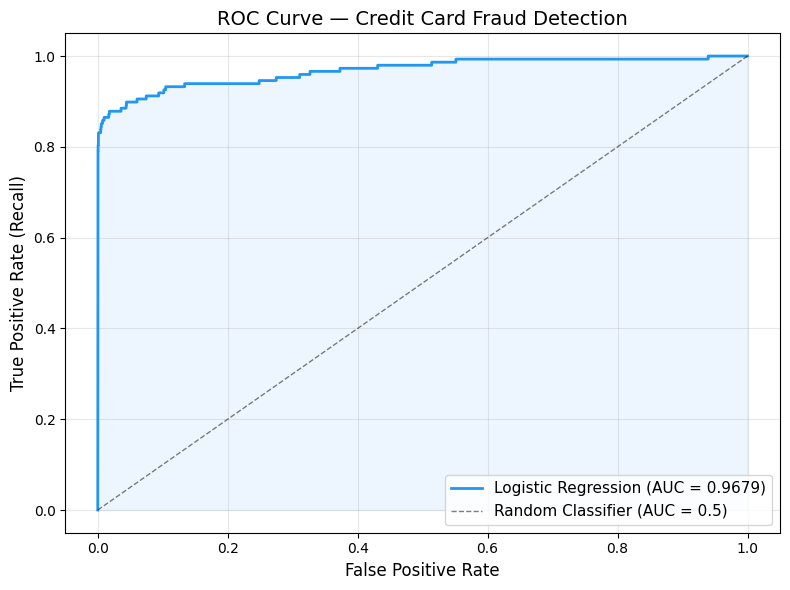


ROC-AUC Score: 0.9679


In [11]:
from sklearn.metrics import roc_curve

# Compute ROC Curve
fpr, tpr, roc_thresholds = roc_curve(y_test, prob[:, 1])
auc_score = roc_auc_score(y_test, prob[:, 1])

# --- Plot ROC Curve ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#2196F3', lw=2, label=f'Logistic Regression (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#2196F3')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve — Credit Card Fraud Detection', fontsize=14)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nROC-AUC Score: {auc_score:.4f}")

In [12]:
# --- Find Optimal Threshold with FPR ≤ 5% Business Constraint ---
fpr_limit = 0.05
valid_indices = np.where(fpr <= fpr_limit)[0]
index = valid_indices[-1]
optimal_threshold = roc_thresholds[index]

print(f"Business Constraint   : FPR ≤ {fpr_limit:.0%}")
print(f"Optimal Threshold     : {optimal_threshold:.4f}")
print(f"True Positive Rate    : {tpr[index]:.4f}  (fraud cases caught)")
print(f"False Positive Rate   : {fpr[index]:.4f}  (legitimate customers affected)")

Business Constraint   : FPR ≤ 5%
Optimal Threshold     : 0.3181
True Positive Rate    : 0.8986  (fraud cases caught)
False Positive Rate   : 0.0441  (legitimate customers affected)


  EVALUATION AT ROC-OPTIMAL THRESHOLD (0.3181)

              precision    recall  f1-score   support

  Legitimate       1.00      0.96      0.98     85295
       Fraud       0.03      0.90      0.07       148

    accuracy                           0.96     85443
   macro avg       0.52      0.93      0.52     85443
weighted avg       1.00      0.96      0.98     85443



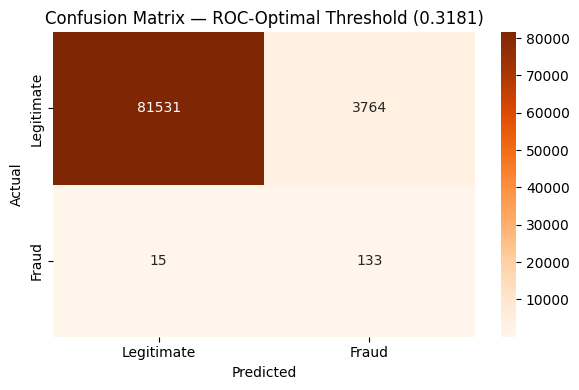

In [13]:
# --- Evaluate Model at ROC-Optimal Threshold ---
predictions_roc = (y_pred_proba >= optimal_threshold).astype(int)

print("=" * 55)
print(f"  EVALUATION AT ROC-OPTIMAL THRESHOLD ({optimal_threshold:.4f})")
print("=" * 55)
print(f"\n{classification_report(y_test, predictions_roc, target_names=['Legitimate', 'Fraud'])}")

fig, ax = plt.subplots(figsize=(6, 4))
cm_roc = confusion_matrix(y_test, predictions_roc)
sns.heatmap(cm_roc, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — ROC-Optimal Threshold ({optimal_threshold:.4f})')
plt.tight_layout()
plt.show()

## 🔄 Step 10 — Precision-Recall Curve & Equilibrium Threshold

The **Precision-Recall (PR) Curve** is more informative than ROC for imbalanced datasets.

### Why PR Curve over ROC in Fraud Detection?

ROC curves can look overly optimistic when the negative class (legitimate) dominates, because FPR is diluted by the massive number of true negatives. The PR curve focuses exclusively on the **positive class (fraud)**, providing a more honest evaluation for rare-event detection.

### Precision-Recall Equilibrium Point

We find the threshold where **Precision ≈ Recall** — the equilibrium point.

> **Business Meaning:** This is the operating point where the model is equally good at:
> - **Not crying wolf** (precision) — every flagged transaction is worth investigating
> - **Not missing fraud** (recall) — every real fraud case gets caught

### Choosing Between Threshold Strategies

| Business Priority | Strategy | How |
|---|---|---|
| Minimize customer friction | Maximize Precision | Raise threshold |
| Minimize financial loss | Maximize Recall | Lower threshold |
| Balance both | Precision = Recall equilibrium | Use PR curve |
| Regulatory FPR requirement | FPR ≤ 5% constraint | Use ROC curve |

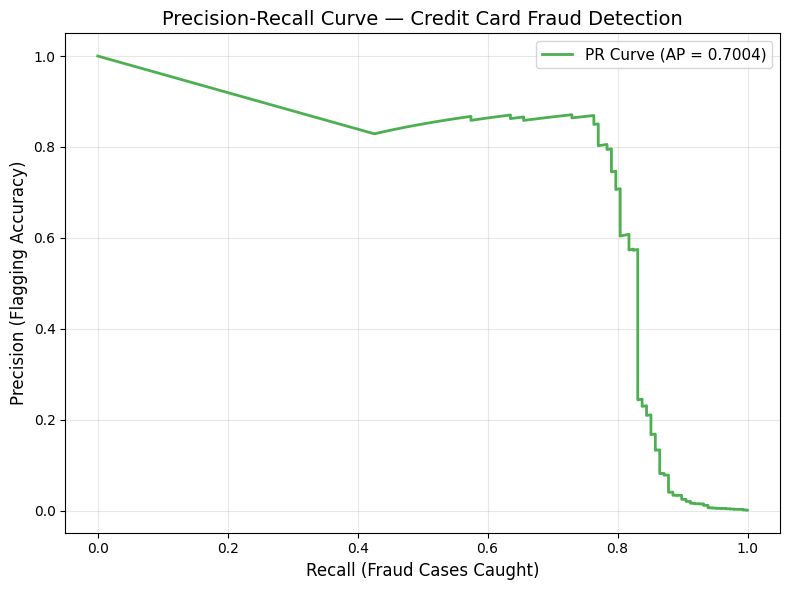


Average Precision (AP): 0.7004


In [14]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Compute Precision-Recall Curve
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test, prob[:, 1])
avg_precision = average_precision_score(y_test, prob[:, 1])

# --- Plot Precision-Recall Curve ---
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(recall_curve, precision_curve, color='#4CAF50', lw=2,
        label=f'PR Curve (AP = {avg_precision:.4f})')
ax.set_xlabel('Recall (Fraud Cases Caught)', fontsize=12)
ax.set_ylabel('Precision (Flagging Accuracy)', fontsize=12)
ax.set_title('Precision-Recall Curve — Credit Card Fraud Detection', fontsize=14)
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAverage Precision (AP): {avg_precision:.4f}")

In [15]:
# --- Find Precision-Recall Equilibrium Point ---
metric_df = pd.DataFrame({
    'threshold': pr_thresholds,
    'precision': precision_curve[:-1],
    'recall': recall_curve[:-1]
})

# Closest point where Precision ≈ Recall
metric_df['gap'] = abs(metric_df['precision'] - metric_df['recall'])
equilibrium_row = metric_df.loc[metric_df['gap'].idxmin()]

print("Precision-Recall Equilibrium Point:")
print(f"  Threshold : {equilibrium_row['threshold']:.4f}")
print(f"  Precision : {equilibrium_row['precision']:.4f}")
print(f"  Recall    : {equilibrium_row['recall']:.4f}")
print(f"  Gap       : {equilibrium_row['gap']:.6f}")

Precision-Recall Equilibrium Point:
  Threshold : 1.0000
  Precision : 0.7905
  Recall    : 0.7905
  Gap       : 0.000000


## 🏁 Step 11 — Threshold Comparison & Final Recommendation

Now we compare all threshold strategies side by side to make a final, data-driven business recommendation.

| Strategy | Source | When to Use |
|---|---|---|
| **Default (0.5)** | Sklearn default | Baseline / general-purpose |
| **ROC-Optimal (FPR ≤ 5%)** | Step 9 | Regulatory / customer-first deployment |
| **PR Equilibrium** | Step 10 | Balanced fraud operations |

> **Final Selection Criteria:** The right threshold depends on the organization's **risk appetite**, **regulatory environment**, and **operational capacity** for manual fraud review.

In [16]:
# --- Side-by-Side Comparison of All Threshold Strategies ---
strategies = {
    'Default (0.50)': 0.5,
    f'ROC-Optimal ({optimal_threshold:.4f})': optimal_threshold,
    f'PR-Equilibrium ({equilibrium_row["threshold"]:.4f})': equilibrium_row['threshold']
}

comparison_results = []
for name, thresh in strategies.items():
    preds = (y_pred_proba >= thresh).astype(int)
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    cm_temp = confusion_matrix(y_test, preds)
    comparison_results.append({
        'Strategy': name,
        'Threshold': round(thresh, 4),
        'Precision (Fraud)': round(report['1']['precision'], 4),
        'Recall (Fraud)': round(report['1']['recall'], 4),
        'F1 (Fraud)': round(report['1']['f1-score'], 4),
        'False Positives': int(cm_temp[0][1]),
        'Missed Fraud (FN)': int(cm_temp[1][0])
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df.set_index('Strategy', inplace=True)
comparison_df

,Threshold,Precision (Fraud),Recall (Fraud),F1 (Fraud),False Positives,Missed Fraud (FN)
Strategy,,,,,,
Default (0.50),0.5000,0.0671,0.8784,0.1248,1806,18
ROC-Optimal (0.3181),0.3181,0.0341,0.8986,0.0658,3764,15
PR-Equilibrium (1.0000),1.0000,0.7905,0.7905,0.7905,31,31


---

## ✅ Executive Summary & Business Conclusions

### What We Built

A **Logistic Regression classifier** for credit card fraud detection, optimized for **real-world business deployment** — not just test-set accuracy. The focus throughout has been on interpretability, cost-sensitive decision-making, and actionable threshold selection.

---

### Key Results

| Threshold Strategy | Business Use |
|---|---|
| **Default (0.5)** | Baseline only — not optimized for fraud detection |
| **ROC-Optimal (FPR ≤ 5%)** | Regulatory / customer-first — limits false alarms to 5% of legitimate transactions |
| **PR Equilibrium** | Balanced operations — equal precision and recall |
| **Custom Low Threshold** | Fraud-loss-minimization — catches maximum fraud at cost of more false alarms |

---

### Business Takeaways

1. **Accuracy is a vanity metric** in fraud detection. A model with 99.8% accuracy that predicts everything as "normal" is completely useless. We must evaluate using Precision, Recall, and AUC.

2. **Threshold selection is a business decision**, not a statistical one. It requires cross-functional alignment between Data Science, Fraud Operations, Risk, and Finance teams.

3. **`class_weight='balanced'` is necessary but not sufficient.** It must be paired with threshold tuning and cost-sensitive evaluation to be effective in production.

4. **Model interpretability matters.** Logistic Regression was chosen because its coefficients can be explained to regulators, compliance teams, and business stakeholders — a critical requirement in the financial industry.

5. **Deployment requires ongoing monitoring.** Fraud patterns evolve — models must be retrained regularly and monitored for performance drift.

---

### Recommended Next Steps

- [ ] Build a **cost-benefit matrix** to quantify exact financial impact at each threshold
- [ ] Add **feature importance analysis** using model coefficients and odds ratios
- [ ] Experiment with **SMOTE / undersampling** to compare with `class_weight` approach
- [ ] Test **ensemble models** (Random Forest, XGBoost) and compare ROC-AUC
- [ ] Build a **real-time scoring API** with configurable threshold endpoint
- [ ] Set up a **model monitoring dashboard** to track precision/recall over time in production

 

---

## ⚠️ Model Constraints & Honest Assessment

Before declaring this model production-ready, it is critical to understand its real limitations — because in financial systems, a false sense of confidence is more dangerous than acknowledged uncertainty.

---

### 1. Precision is Too Low for Standalone Deployment

| Operating Point | Precision | False Positives | Implication |
|---|---|---|---|
| Default (0.50) | **6.7%** | 1,806 | 14 false alarms per real fraud caught |
| ROC-Optimal (0.3181) | **3.4%** | 3,764 | 28 false alarms per real fraud caught |
| PR-Equilibrium (1.00) | **79%** | 31 | Acceptable, but only catches 79% of fraud |

> **Real-World Impact:** If deployed standalone, a fraud analyst team would need to review thousands of false alerts daily. At scale, this leads to **alert fatigue** — analysts start ignoring flags, defeating the entire purpose of the system.

---

### 2. The Precision-Recall Cliff

Looking at the PR curve, precision holds steady (80-87%) until ~78% recall, then **drops sharply to near zero**. This means catching that last 10-20% of fraud is extremely expensive in terms of false positives — a classic characteristic of highly imbalanced datasets.

---

### 3. Features Are Anonymized (V1–V28)

The dataset uses PCA-transformed features for privacy compliance. This means:
- We cannot validate whether the features *make business sense*
- Model coefficients, while technically explainable, cannot be translated into actionable fraud patterns for investigators
- In production, you'd work with raw features (merchant category, geolocation, time patterns) which this model has never seen

---

### 4. No Temporal Validation

The data is from **September 2013 — a single two-day period**. Fraud patterns evolve rapidly. This model:
- Has not been tested on out-of-time data
- May be capturing artifacts of that specific time period
- Would likely degrade significantly within months of deployment without retraining

---

### 5. Static Threshold — No Feedback Loop

The threshold is set once and evaluated on a static test set. Production systems require:
- Dynamic threshold adjustment based on fraud team capacity
- Real-time feedback when analysts confirm/reject flags
- Drift monitoring to detect when the model's score distribution shifts

---

## 🚀 Roadmap to Full Production Readiness

Here is a structured, prioritized path from this notebook to a system a financial institution could actually deploy:

---

### Phase 1 — Improve the Model Itself

| Action | Goal | Expected Impact |
|---|---|---|
| **Add SMOTE / undersampling** | Rebalance training data | Improve precision at high recall |
| **Feature engineering** | Create velocity, time-delta, merchant-risk features | Stronger signal, better separation |
| **Try XGBoost / LightGBM** | Non-linear model with better imbalance handling | Likely +5-10% ROC-AUC, much better PR-AUC |
| **Cross-validation (StratifiedKFold)** | Validate stability across multiple splits | Confirm results aren't train-test-split lucky |
| **Out-of-time validation** | Test on a later time window | Measure true generalization |

---

### Phase 2 — Build a Cost-Aware Evaluation Framework

| Action | Goal |
|---|---|
| **Build a cost-benefit matrix** | Quantify: `savings from caught fraud` vs `cost of false alert investigation` |
| **Compute expected monetary value per threshold** | Select threshold that maximizes financial outcome, not just F1 |
| **Add SHAP / odds-ratio analysis** | Explain individual predictions — required by banking regulators (SR 11-7, GDPR Art. 22) |

---

### Phase 3 — Production Architecture

```
Transaction arrives
        │
        ▼
 Rule Engine (fast, explicit rules)
  e.g. foreign country + >€5000 → auto-block
        │
        ▼ (passes rules)
 ML Model Score (this model)
  Score < 0.15 → Auto-approve
  0.15 ≤ Score < 0.80 → Risk-based step-up (OTP, call)
  Score ≥ 0.80 → Auto-block + analyst queue
        │
        ▼
 Analyst Reviews Queue
  → Confirms fraud → retraining signal
  → Dismisses → false positive log
        │
        ▼
 Model Monitoring Dashboard
  Tracks: score distribution drift, precision/recall over time
  Triggers: retraining pipeline when performance degrades
```

---

### Phase 4 — Compliance & Governance

| Requirement | How to Address |
|---|---|
| **Model explainability** | SHAP values for each prediction, logged per transaction |
| **Audit trail** | Every decision (approve/block/review) logged with model version + score |
| **Model versioning** | MLflow or similar for reproducible experiments |
| **Regulatory documentation** | Model card describing training data, known limitations, evaluation methodology |
| **Bias testing** | Ensure model doesn't disproportionately flag transactions from specific regions/demographics |

---

> **Conclusion:** This model is an excellent **proof of concept and learning demonstration**. Its ROC-AUC of 0.9679 proves the signal exists and the algorithm works. The path to production is not about the algorithm — it's about building the surrounding system: better features, cost-aware evaluation, a multi-tier decision pipeline, and continuous monitoring.

---

*Notebook by: Muhammad Taha | Dataset: [Kaggle Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)*
---


## **Thank You for Reviewing**
Thank you for following along with this notebook. If you have any questions, feedback, or suggestions, feel free to reach out. Happy coding! 

### **Connect with me:**
LinkedIn: [Muhammad Taha](https://linkedin.com/in/muhammad-taha-b88807248/) \
GitHub: [MuhammadTaha1038](https://github.com/MuhammadTaha1038) \
Kaggle: [muhammadtaha1038](https://www.kaggle.com/muhammadtaha1038) 